<a href="https://colab.research.google.com/github/Mytros/DS_ML_homework/blob/main/HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C_Dmytro_Koval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [2]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
''' https://github.com/Mytros/DS_ML_homework/blob/main/process_bank_churn.py '''

' https://github.com/Mytros/DS_ML_homework/blob/main/process_bank_churn.py '

In [5]:
!wget -O process_bank_churn.py https://raw.githubusercontent.com/Mytros/DS_ML_homework/main/process_bank_churn.py



--2025-07-17 22:07:32--  https://raw.githubusercontent.com/Mytros/DS_ML_homework/main/process_bank_churn.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4865 (4.8K) [text/plain]
Saving to: ‘process_bank_churn.py’

process_bank_churn. 100%[===================>]   4.75K  --.-KB/s    in 0s      

2025-07-17 22:07:33 (51.2 MB/s) - ‘process_bank_churn.py’ saved [4865/4865]



In [6]:
!ls

drive  process_bank_churn.py  sample_data


In [7]:
from process_bank_churn import preprocess_data


In [8]:
raw_df = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/train.csv")
X_train, y_train, X_val, y_val, input_cols, scaler, encoder = preprocess_data(raw_df, scaler_numeric=False)
df = preprocess_data(raw_df)

In [9]:
df

(          id  CustomerId  CreditScore   Age  Tenure    Balance  NumOfProducts  \
 7180    7180  15652218.0        682.0  30.0     1.0  131394.56            1.0   
 10393  10393  15592937.0        684.0  39.0     2.0  178058.06            1.0   
 80        80  15774586.0        705.0  35.0     6.0  116320.68            2.0   
 3365    3365  15780572.0        669.0  58.0     0.0       0.00            2.0   
 12236  12236  15642099.0        707.0  21.0     3.0       0.00            2.0   
 ...      ...         ...          ...   ...     ...        ...            ...   
 9493    9493  15711299.0        633.0  33.0     4.0       0.00            2.0   
 8463    8463  15778418.0        673.0  40.0     1.0       0.00            1.0   
 8143    8143  15585192.0        621.0  29.0     8.0       0.00            2.0   
 11512  11512  15694450.0        590.0  42.0     7.0       0.00            2.0   
 9360    9360  15636413.0        545.0  27.0     2.0       0.00            2.0   
 
        HasCrC

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

Train AUC: 1.0000
Validation AUC: 0.7605
Tree depth: 23


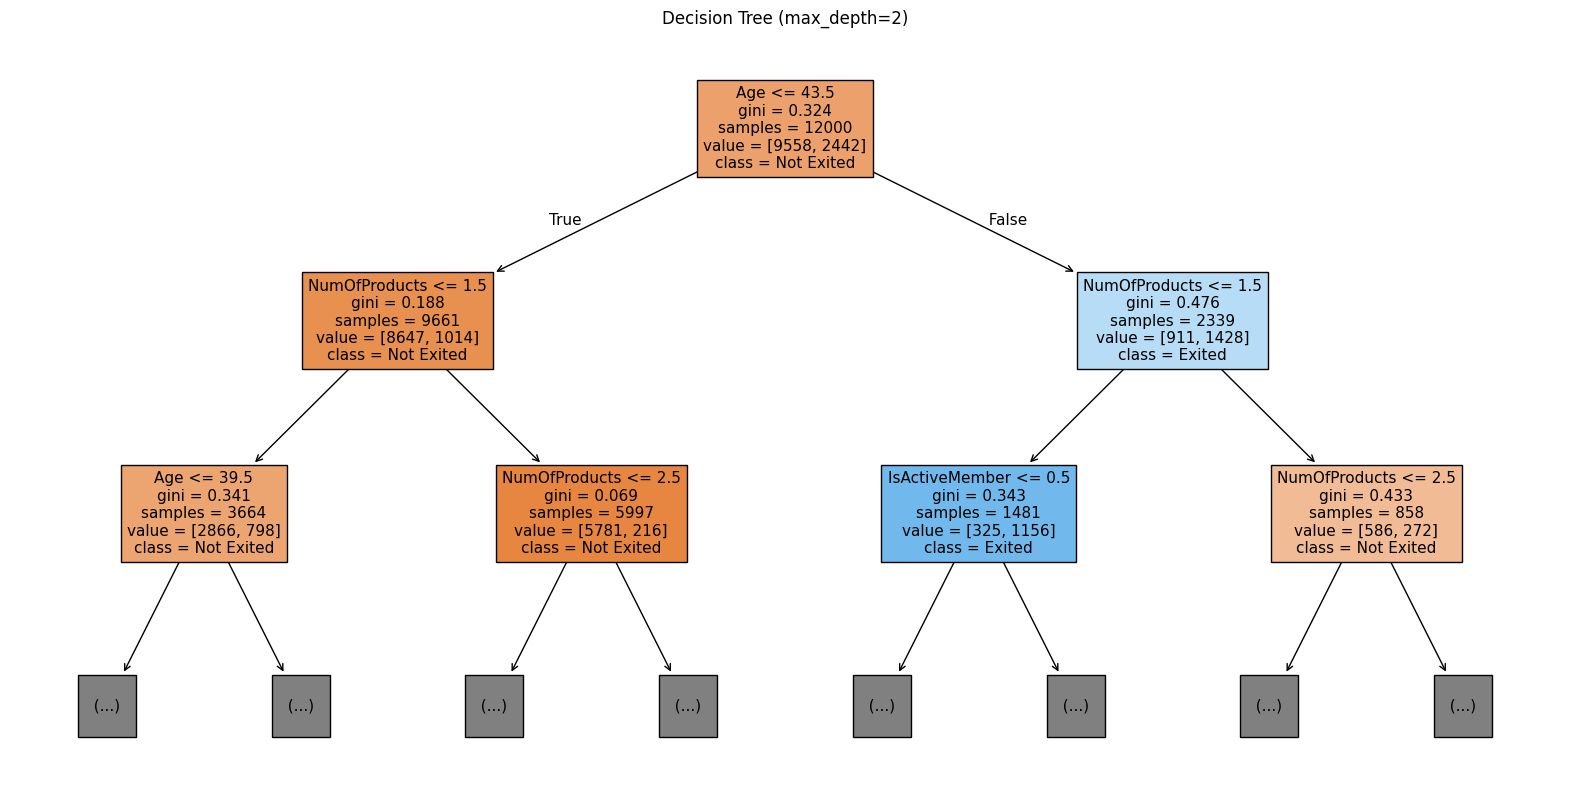

,feature,importance
3,Age,0.339715
6,NumOfProducts,0.168379
9,EstimatedSalary,0.075879
1,CustomerId,0.075051
0,id,0.073747
5,Balance,0.072693
2,CreditScore,0.070632
4,Tenure,0.038542
8,IsActiveMember,0.033198
11,Geography_Germany,0.015516


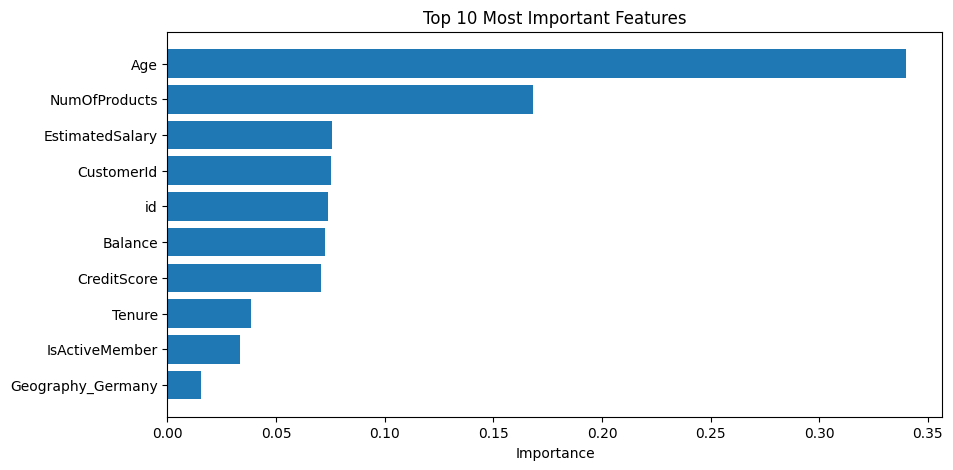

In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

# 1.train
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 2. AUC (ROC) train vs validation
train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"Train AUC: {train_auc:.4f}")
print(f"Validation AUC: {val_auc:.4f}")

# 3. tree depth
print("Tree depth:", model.get_depth())

# 4. tree depth = 2
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    max_depth=2,
    feature_names=input_cols,
    class_names=['Not Exited', 'Exited'],
    filled=True
)
plt.title("Decision Tree (max_depth=2)")
plt.show()

# 5. top 10 important
importance_df = pd.DataFrame({
    'feature': input_cols,
    'importance': model.feature_importances_
})

top10 = importance_df.sort_values(by='importance', ascending=False).head(10)
display(top10)

# figure
plt.figure(figsize=(10, 5))
plt.barh(top10['feature'], top10['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.show()


**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# Random manual parameters
param_grid = [
    {"max_depth": 3, "max_leaf_nodes": None},
    {"max_depth": 5, "max_leaf_nodes": None},
    {"max_depth": 7, "max_leaf_nodes": None},
    {"max_depth": None, "max_leaf_nodes": 10},
    {"max_depth": None, "max_leaf_nodes": 20},
    {"max_depth": 5, "max_leaf_nodes": 15},
    {"max_depth": 8, "max_leaf_nodes": 25},
    {"max_depth": 8, "max_leaf_nodes": 20},
]

results = []

# test loop
for params in param_grid:
    model = DecisionTreeClassifier(random_state=42, **params)
    model.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    results.append({
        "params": params,
        "train_auc": train_auc,
        "val_auc": val_auc
    })

# results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="val_auc", ascending=False).reset_index(drop=True)
display(results_df)


,params,train_auc,val_auc
0,"{'max_depth': 5, 'max_leaf_nodes': None}",0.925766,0.923464
1,"{'max_depth': 8, 'max_leaf_nodes': 25}",0.920477,0.919113
2,"{'max_depth': None, 'max_leaf_nodes': 20}",0.917903,0.917276
3,"{'max_depth': 8, 'max_leaf_nodes': 20}",0.917903,0.917276
4,"{'max_depth': 7, 'max_leaf_nodes': None}",0.941928,0.917229
5,"{'max_depth': 5, 'max_leaf_nodes': 15}",0.913437,0.913118
6,"{'max_depth': None, 'max_leaf_nodes': 10}",0.901475,0.900218
7,"{'max_depth': 3, 'max_leaf_nodes': None}",0.897184,0.891146


Найкращі показники у моделі з глибиною 5 і без вказування max_leaf_nodes.

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

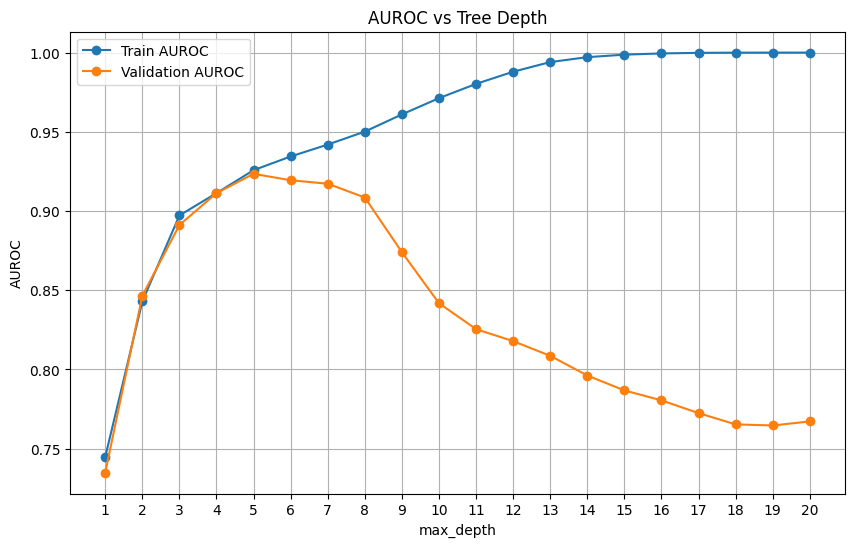

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

train_auc_list = []
val_auc_list = []
depth_range = list(range(1, 21))

# max_depth - 1 - 20
for depth in depth_range:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    train_auc_list.append(train_auc)
    val_auc_list.append(val_auc)

# Figure
plt.figure(figsize=(10, 6))
plt.plot(depth_range, train_auc_list, label='Train AUROC', marker='o')
plt.plot(depth_range, val_auc_list, label='Validation AUROC', marker='o')
plt.xlabel('max_depth')
plt.ylabel('AUROC')
plt.title('AUROC vs Tree Depth')
plt.legend()
plt.grid(True)
plt.xticks(depth_range)
plt.show()


Найкращий показник = 5 - значення, після якого починаються розходитися графіки.

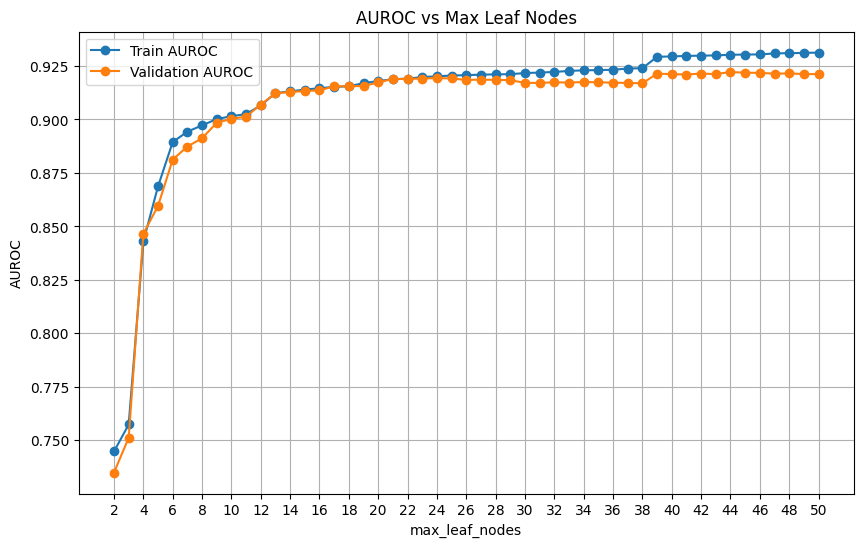

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

train_auc_list = []
val_auc_list = []
leaf_range = list(range(2, 51))  # leaves range

for max_leaf in leaf_range:
    model = DecisionTreeClassifier(max_leaf_nodes=max_leaf, random_state=42)
    model.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    train_auc_list.append(train_auc)
    val_auc_list.append(val_auc)

# Figure
plt.figure(figsize=(10, 6))
plt.plot(leaf_range, train_auc_list, label='Train AUROC', marker='o')
plt.plot(leaf_range, val_auc_list, label='Validation AUROC', marker='o')
plt.xlabel('max_leaf_nodes')
plt.ylabel('AUROC')
plt.title('AUROC vs Max Leaf Nodes')
plt.legend()
plt.grid(True)
plt.xticks(leaf_range[::2])  # step =2
plt.show()


max leaf nodes = приблизно 24

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [17]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_leaf_nodes=24, max_depth=8, random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=8, max_leaf_nodes=24, random_state=42)

In [18]:
test_df = pd.read_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/test.csv")
test_ids = test_df["id"]


In [19]:
from process_bank_churn import preprocess_new_data

X_test = preprocess_new_data(test_df, input_cols=input_cols, encoder=encoder, scaler=scaler)


In [20]:
test_preds = model.predict_proba(X_test)[:, 1]


In [21]:
import pandas as pd

submission_df = pd.DataFrame({
    "id": test_ids,
    "prediction": test_preds
})

submission_df.to_csv("/content/drive/MyDrive/DS_ML/bank-customer-churn-prediction-dlu-course-c-3/submission_tree.csv", index=False)



In [22]:


train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train, train_probs)
val_auc = roc_auc_score(y_val, val_probs)

print(f"Train AUROC: {train_auc:.4f}")
print(f"Validation AUROC: {val_auc:.4f}")


Train AUROC: 0.9201
Validation AUROC: 0.9193


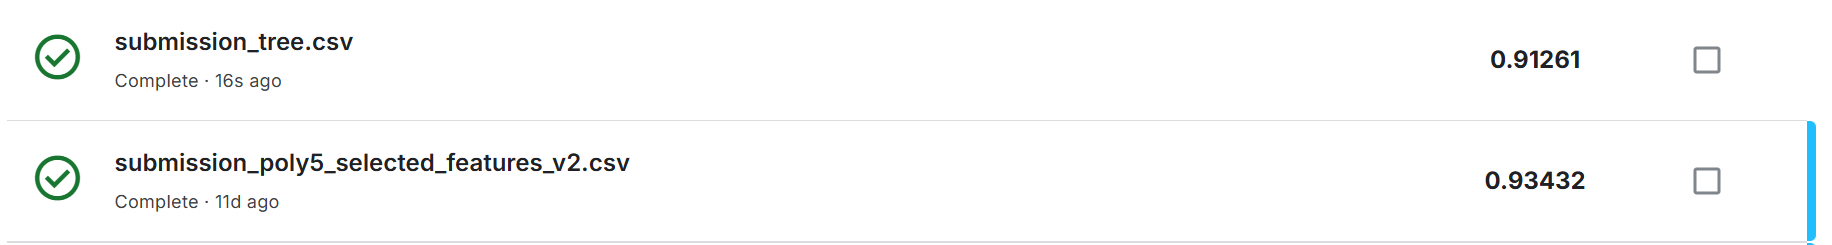